# Experience-Centered AI Rankings & Visualization

This notebook applies the Experience-Centered AI framework to a set of companies across multiple industries.

Each company receives a composite Experience AI Score based on six dimensions:

- Experience Intensity
- AI Enhancement Potential
- Repeat Usage
- Agency Preservation
- Revenue Capture
- Network Effects

The objective is to evaluate which companies appear best positioned to create value through AI systems that enhance participation, engagement, learning, creativity, and mastery rather than simply replacing human effort.

This notebook produces:

1. Company-level rankings
2. Industry-level rankings
3. Visual comparisons of company scores
4. Visual comparisons of industry averages
5. Initial observations and strategic implications

The rankings generated here serve as the foundation for subsequent sensitivity testing and financial analysis.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd

from scripts.visualization import (
    save_company_ranking_chart,
    save_industry_ranking_chart
)

DATA_PATH = project_root / "data" / "raw" / "scoring.csv"
CHART_DIR = project_root / "charts"

CHART_DIR.mkdir(exist_ok=True)

In [2]:
# Load scoring data exported from Excel

df = pd.read_csv(DATA_PATH)

df.head()

,company_id,company,industry,experience_intensity,ai_enhancement,repeat_usage,agency_preservation,revenue_capture,network_effects,experience_ai_score
0,1,Peloton,Fitness,10,9,8,9,8,6,8.65
1,2,Planet Fitness,Fitness,7,6,7,8,8,4,6.75
2,3,Duolingo,Education,9,10,10,9,9,7,9.20
3,4,Coursera,Education,8,8,7,8,7,5,7.40
4,5,Roblox,Gaming,10,9,10,10,9,10,9.70


In [3]:
# Rank companies by Experience AI Score

company_rankings = (
    df.sort_values("experience_ai_score", ascending=False)
      [["company", "industry", "experience_ai_score"]]
      .reset_index(drop=True)
)

company_rankings.insert(0, "rank", company_rankings.index + 1)

company_rankings

,rank,company,industry,experience_ai_score
0,1,Roblox,Gaming,9.70
1,2,Duolingo,Education,9.20
2,3,Match Group,Dating,8.85
3,4,Peloton,Fitness,8.65
4,5,Bumble,Dating,8.65
5,6,Spotify,Entertainment,8.35
6,7,Electronic Arts,Gaming,8.25
7,8,Netlix,Entertainment,7.95
8,9,HelloFresh,Food/Cooking,7.75
9,10,Airbnb,Travel,7.70


## Company Rankings

These rankings represent each company's alignment with the Experience-Centered AI framework.

Higher scores indicate stronger potential to create value through AI systems that enhance human participation rather than replace it.

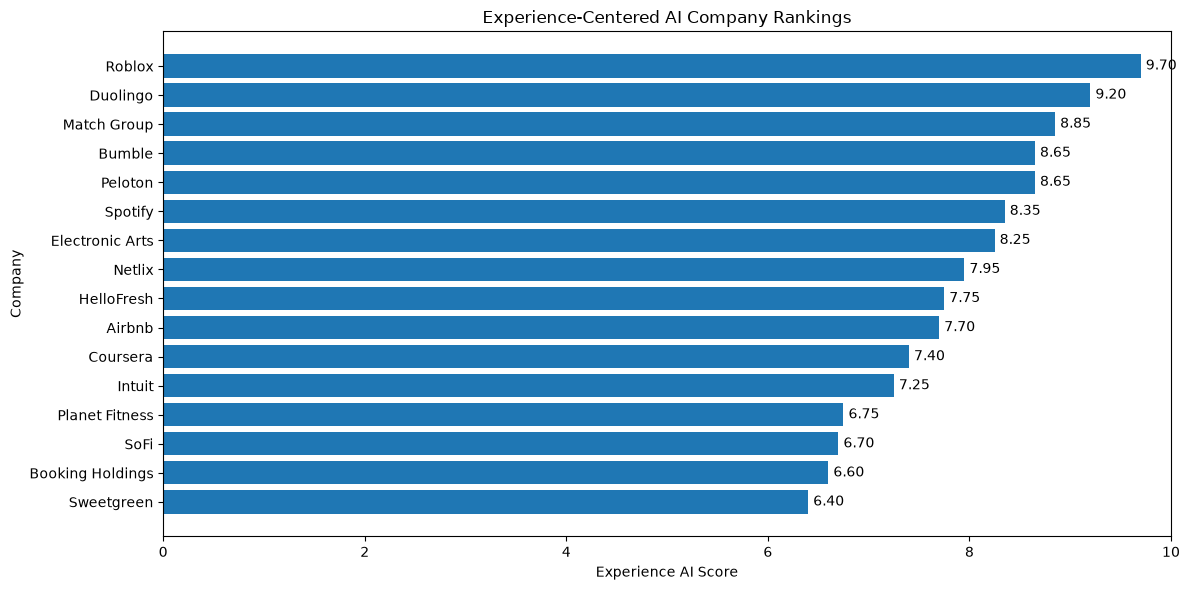

In [4]:
# Generate and save company ranking chart

save_company_ranking_chart(
    df,
    CHART_DIR
)

In [5]:
# Calculate average Experience AI Score by industry

industry_scores = (
    df.groupby("industry", as_index=False)["experience_ai_score"]
      .mean()
      .sort_values("experience_ai_score", ascending=False)
      .reset_index(drop=True)
)

industry_scores.insert(0, "rank", industry_scores.index + 1)

industry_scores

,rank,industry,experience_ai_score
0,1,Gaming,8.975
1,2,Dating,8.750
2,3,Education,8.300
3,4,Entertainment,8.150
4,5,Fitness,7.700
5,6,Travel,7.150
6,7,Food/Cooking,7.075
7,8,Personal Finance,6.975


## Industry Rankings

Industry-level scores show which categories are most aligned with the Experience-Centered AI thesis.

Higher-scoring industries tend to involve identity, mastery, engagement, repeat usage, and preserved user agency.

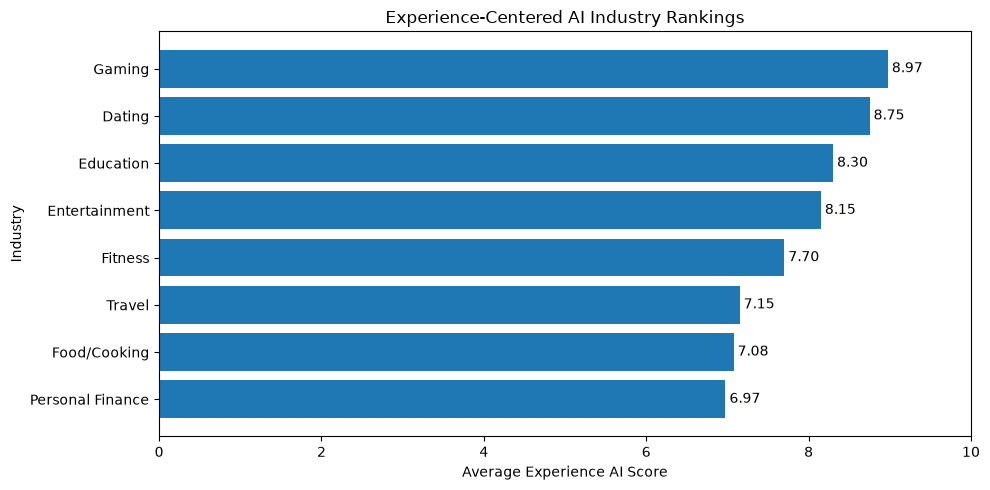

,industry,experience_ai_score
6,Personal Finance,6.975
4,Food/Cooking,7.075
7,Travel,7.150
3,Fitness,7.700
2,Entertainment,8.150
1,Education,8.300
0,Dating,8.750
5,Gaming,8.975


In [6]:
# Generate and save industry ranking chart

save_industry_ranking_chart(
    df,
    CHART_DIR
)

In [7]:
# Compare companies across the six scoring dimensions

factor_cols = [
    "experience_intensity",
    "ai_enhancement",
    "repeat_usage",
    "agency_preservation",
    "revenue_capture",
    "network_effects"
]

factor_table = (
    df[["company"] + factor_cols]
    .set_index("company")
)

factor_table

,experience_intensity,ai_enhancement,repeat_usage,agency_preservation,revenue_capture,network_effects
company,,,,,,
Peloton,10,9,8,9,8,6
Planet Fitness,7,6,7,8,8,4
Duolingo,9,10,10,9,9,7
Coursera,8,8,7,8,7,5
Roblox,10,9,10,10,9,10
Electronic Arts,9,8,8,8,9,7
Intuit,6,9,8,5,10,6
SoFi,6,8,7,6,8,5
Airbnb,8,8,5,8,9,10


In [8]:
# Calculate average factor scores by industry

industry_factor_scores = (
    df.groupby("industry")[factor_cols]
      .mean()
      .round(2)
)

industry_factor_scores

,experience_intensity,ai_enhancement,repeat_usage,agency_preservation,revenue_capture,network_effects
industry,,,,,,
Dating,9.0,9.0,9.0,8.0,8.5,8.5
Education,8.5,9.0,8.5,8.5,8.0,6.0
Entertainment,8.0,8.5,9.5,6.0,8.5,8.0
Fitness,8.5,7.5,7.5,8.5,8.0,5.0
Food/Cooking,7.0,7.5,6.5,7.5,7.0,7.0
Gaming,9.5,8.5,9.0,9.0,9.0,8.5
Personal Finance,6.0,8.5,7.5,5.5,9.0,5.5
Travel,7.0,7.5,5.0,7.0,9.5,9.0


In [9]:
# Identify the strongest company for each framework dimension

top_by_factor = {}

for factor in factor_cols:
    top_row = df.loc[df[factor].idxmax()]
    top_by_factor[factor] = {
        "company": top_row["company"],
        "score": top_row[factor]
    }

top_by_factor_df = pd.DataFrame(top_by_factor).T

top_by_factor_df

,company,score
experience_intensity,Peloton,10
ai_enhancement,Duolingo,10
repeat_usage,Duolingo,10
agency_preservation,Roblox,10
revenue_capture,Intuit,10
network_effects,Roblox,10


In [10]:
# Calculate average score for each framework dimension across all companies

factor_means = (
    df[factor_cols]
    .mean()
    .sort_values(ascending=False)
)

factor_means

revenue_capture         8.4375
ai_enhancement          8.2500
experience_intensity    7.9375
repeat_usage            7.8125
agency_preservation     7.5000
network_effects         7.1875
dtype: float64

## Score Separation

The gap between the highest and lowest company scores shows meaningful separation across the sample.

This suggests that the framework is producing differentiated rankings rather than clustering all companies around the same score.

In [11]:
# Save processed ranking outputs for later use in README, SQL, or dashboard development

OUTPUT_DIR = project_root / "data" / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

company_rankings.to_csv(OUTPUT_DIR / "company_rankings.csv", index=False)
industry_scores.to_csv(OUTPUT_DIR / "industry_rankings.csv", index=False)
industry_factor_scores.to_csv(OUTPUT_DIR / "industry_factor_scores.csv")

print("Outputs saved to:", OUTPUT_DIR)

Outputs saved to: c:\Users\Owner\OneDrive\Desktop\experience-centered-ai\data\outputs


# Initial Findings

Gaming, Education, Dating, and Entertainment ranked among the strongest industries under the Experience-Centered AI framework.

The highest-scoring companies—Roblox, Duolingo, Match Group, Bumble, Peloton, and Spotify—share several characteristics:

- Frequent user engagement
- Strong identity and self-expression components
- High personalization potential
- Preserved user agency
- Recurring monetization models
- Meaningful opportunities for AI-assisted guidance and discovery

Travel and Food/Cooking produced mixed results, suggesting that meaningful participation alone is insufficient without strong repeat engagement and network effects.

Personal Finance scored lower despite strong monetization potential, indicating that utility-oriented products may be less aligned with the Experience-Centered AI thesis than products centered on learning, relationships, creativity, entertainment, and participation.

These findings should be interpreted as exploratory and directional rather than predictive.

# Key Insights

1. Gaming emerged as the strongest industry under the Experience-Centered AI framework due to exceptional performance in engagement, repeat usage, and network effects.

2. Roblox achieved the highest overall score and demonstrated strength across nearly every framework dimension.

3. Duolingo, Match Group, Bumble, and Spotify scored highly because they combine personalization, habit formation, identity development, and active user participation.

4. Dating platforms ranked higher than expected, suggesting that AI systems which improve matching, coaching, and communication may create substantial value while preserving user agency.

5. Travel and Food/Cooking companies benefited from agency preservation but were limited by lower repeat usage and weaker network effects.

6. Personal Finance companies demonstrated strong monetization potential but lower scores in experience intensity and agency preservation.

7. Across industries, the highest-scoring companies tended to combine engagement, personalization, recurring usage, and meaningful user participation.

8. The results provide preliminary support for the hypothesis that future AI value creation may be concentrated in industries where AI enhances participation, learning, creativity, relationships, and ownership rather than fully automating the user experience.